# 01 — Exploratory Data Analysis (EDA)

**Dataset:** `data/raw/dataset.csv`  
**Kolom:** `review_text` (teks ulasan), `sentiment` (0 = Negatif, 1 = Positif)  
**Tujuan:** Memahami karakteristik data sebelum preprocessing dan modeling.

---

**Daftar Analisis:**
1. Overview Dataset
2. Distribusi Label (Class Balance)
3. Analisis Panjang Teks
4. Word Frequency Analysis (Top Words)
5. WordCloud per Kelas
6. Analisis Karakter Khusus (URL, Mention, Emoji)
7. Deteksi Duplikat & Missing Values
8. Ringkasan & Rekomendasi Preprocessing


## 0. Import Library


In [2]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi'     : 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size'      : 11,
})
PALETTE = ['#e74c3c', '#2ecc71']   # merah = Negatif, hijau = Positif
DATA_PATH = '../data/raw/dataset.csv'
print('✅ Library siap')

✅ Library siap


---
## 1. Overview Dataset


In [3]:
df = pd.read_csv(DATA_PATH)
print('=' * 55)
print('  OVERVIEW DATASET')
print('=' * 55)
print(f'  Jumlah baris   : {len(df):,}')
print(f'  Jumlah kolom   : {df.shape[1]}')
print(f'  Kolom          : {list(df.columns)}')
print(f'  Tipe data      : {dict(df.dtypes)}')
print(f'  Missing values : {df.isnull().sum().to_dict()}')
print(f'  Duplikat       : {df.duplicated().sum()} baris')
print('=' * 55)
df.head(5)

  OVERVIEW DATASET
  Jumlah baris   : 19,728
  Jumlah kolom   : 2
  Kolom          : ['review_text', 'sentiment']
  Tipe data      : {'review_text': dtype('O'), 'sentiment': dtype('int64')}
  Missing values : {'review_text': 0, 'sentiment': 0}
  Duplikat       : 0 baris


,review_text,sentiment
0,pelayanan buruk tidak ada respon warna baju td...,0
1,barang ga bisa berfungsi dg baik .,0
2,"Voucher Netflix zonk! Kdg bs kdg gk, ribet bgt...",0
3,Astaga beli lays kok gini amat. Kirain dpt byk...,0
4,"Dispenser zonk! Air gk dingin sama sekali, pan...",0


In [4]:
# Statistik teks dasar
df['char_count']  = df['review_text'].str.len()
df['word_count']  = df['review_text'].str.split().str.len()
df['sent_label']  = df['sentiment'].map({0: 'Negatif', 1: 'Positif'})

print('Statistik panjang karakter:')
print(df['char_count'].describe().round(1).to_string())
print()
print('Statistik jumlah kata:')
print(df['word_count'].describe().round(1).to_string())

Statistik panjang karakter:
count    19728.0
mean       132.6
std         82.4
min          5.0
25%         61.0
50%        125.0
75%        178.0
max        855.0

Statistik jumlah kata:
count    19728.0
mean        21.9
std         13.5
min          1.0
25%         10.0
50%         21.0
75%         29.0
max        122.0


---
## 2. Distribusi Label


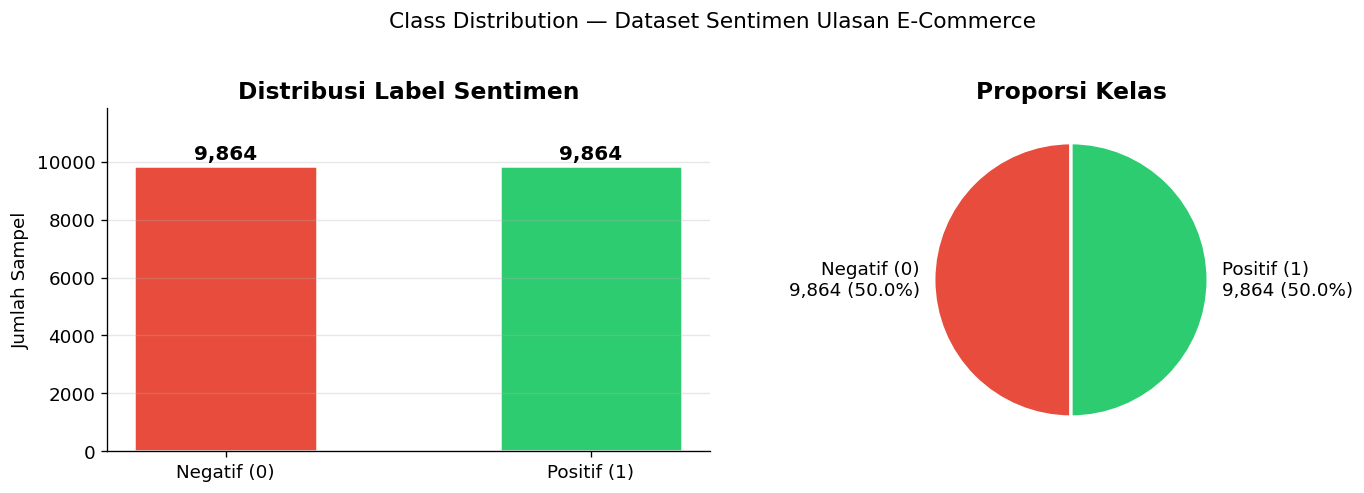


✅ Dataset SEIMBANG — selisih hanya 0.0%
   Negatif: 9,864 | Positif: 9,864


In [5]:
label_counts = df['sentiment'].value_counts().sort_index()
label_names  = ['Negatif (0)', 'Positif (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(label_names, label_counts.values, color=PALETTE, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Distribusi Label Sentimen', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, label_counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[f'{n}\n{v:,} ({v/len(df)*100:.1f}%)' for n, v in zip(label_names, label_counts.values)],
    colors=PALETTE, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution — Dataset Sentimen Ulasan E-Commerce', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

imbalance = abs(label_counts[0] - label_counts[1]) / len(df) * 100
print(f'\n✅ Dataset SEIMBANG — selisih hanya {imbalance:.1f}%')
print(f'   Negatif: {label_counts[0]:,} | Positif: {label_counts[1]:,}')

---
## 3. Analisis Panjang Teks


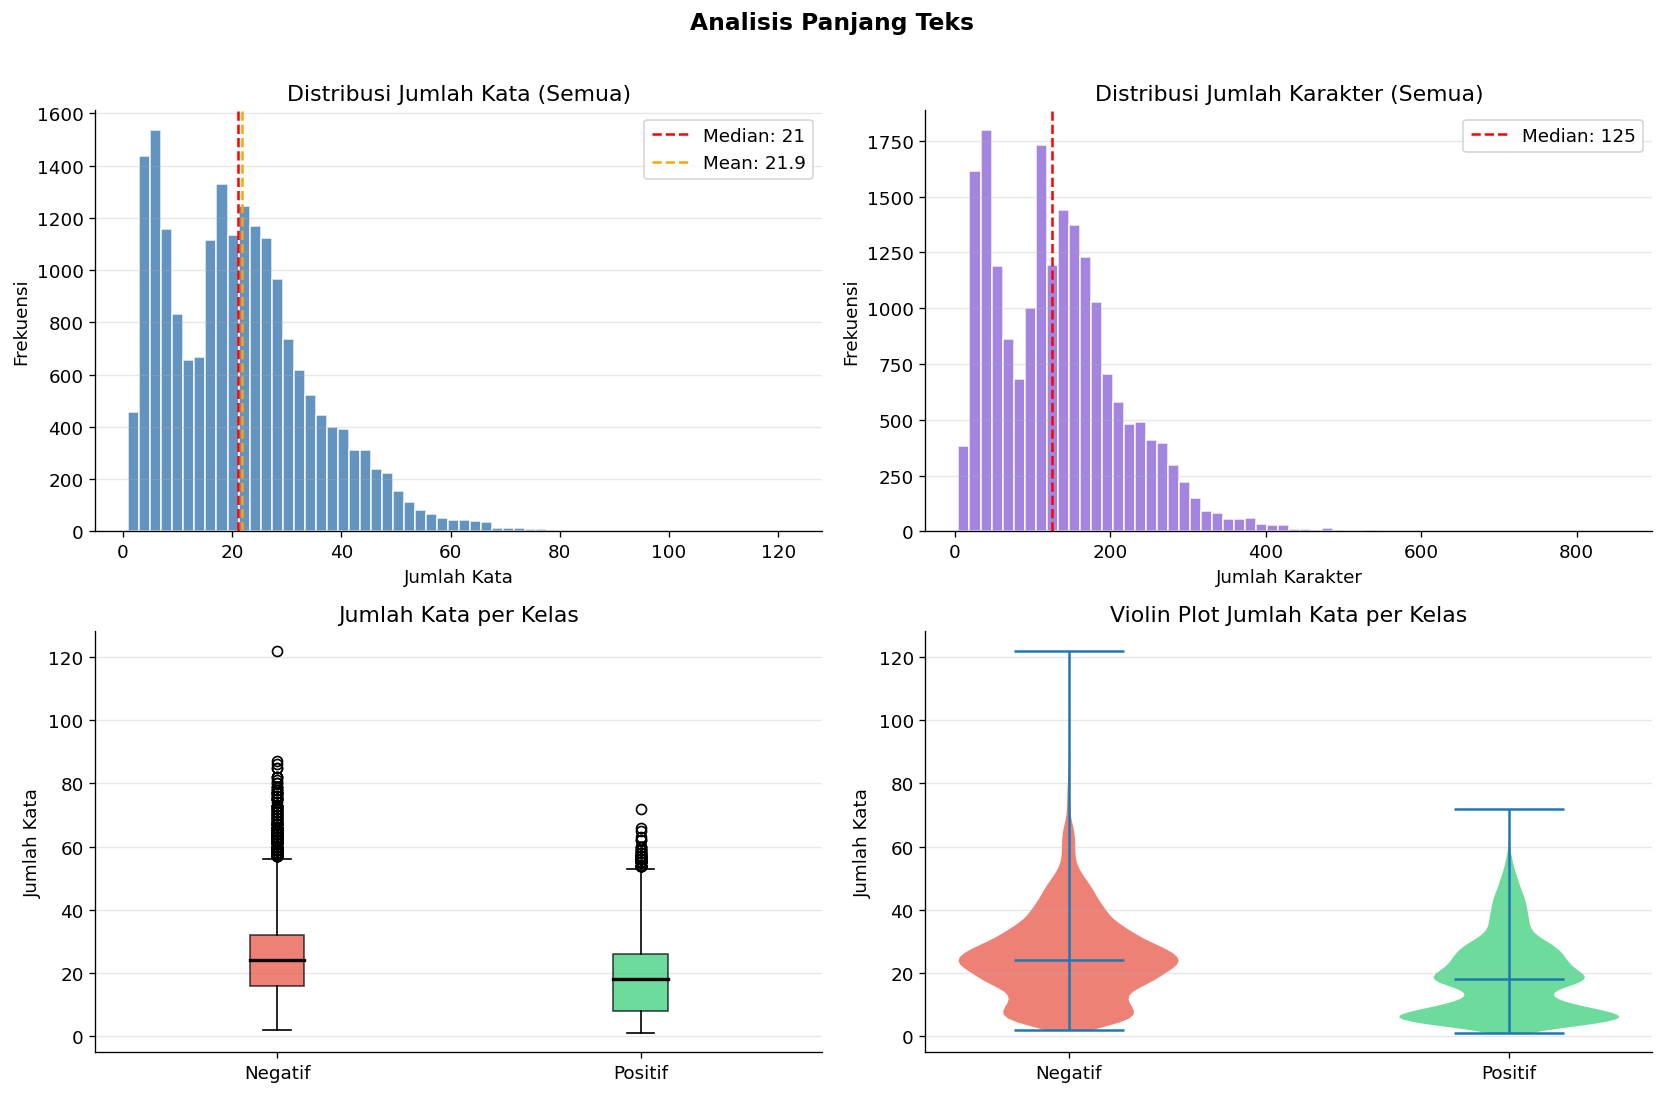


Statistik per kelas:
             count  mean   std  min   25%   50%   75%    max
sent_label                                                  
Negatif     9864.0  25.0  13.7  2.0  16.0  24.0  32.0  122.0
Positif     9864.0  18.8  12.5  1.0   8.0  18.0  26.0   72.0


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Distribusi jumlah kata — keseluruhan
axes[0][0].hist(df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0][0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[0][0].axvline(df['word_count'].mean(),   color='orange', linestyle='--', label=f'Mean: {df["word_count"].mean():.1f}')
axes[0][0].set_title('Distribusi Jumlah Kata (Semua)')
axes[0][0].set_xlabel('Jumlah Kata'); axes[0][0].set_ylabel('Frekuensi')
axes[0][0].legend(); axes[0][0].grid(axis='y', alpha=0.3)

# Distribusi jumlah karakter — keseluruhan
axes[0][1].hist(df['char_count'], bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0][1].axvline(df['char_count'].median(), color='red', linestyle='--', label=f'Median: {df["char_count"].median():.0f}')
axes[0][1].set_title('Distribusi Jumlah Karakter (Semua)')
axes[0][1].set_xlabel('Jumlah Karakter'); axes[0][1].set_ylabel('Frekuensi')
axes[0][1].legend(); axes[0][1].grid(axis='y', alpha=0.3)

# Boxplot jumlah kata per kelas
neg = df[df['sentiment']==0]['word_count']
pos = df[df['sentiment']==1]['word_count']
bp = axes[1][0].boxplot([neg, pos], labels=['Negatif', 'Positif'], patch_artist=True,
                         medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1][0].set_title('Jumlah Kata per Kelas')
axes[1][0].set_ylabel('Jumlah Kata'); axes[1][0].grid(axis='y', alpha=0.3)

# Violin plot
parts = axes[1][1].violinplot([neg, pos], positions=[1,2], showmedians=True)
for pc, color in zip(parts['bodies'], PALETTE):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[1][1].set_xticks([1,2]); axes[1][1].set_xticklabels(['Negatif','Positif'])
axes[1][1].set_title('Violin Plot Jumlah Kata per Kelas')
axes[1][1].set_ylabel('Jumlah Kata'); axes[1][1].grid(axis='y', alpha=0.3)

plt.suptitle('Analisis Panjang Teks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nStatistik per kelas:')
print(df.groupby('sent_label')['word_count'].describe().round(1).to_string())

---
## 4. Word Frequency Analysis


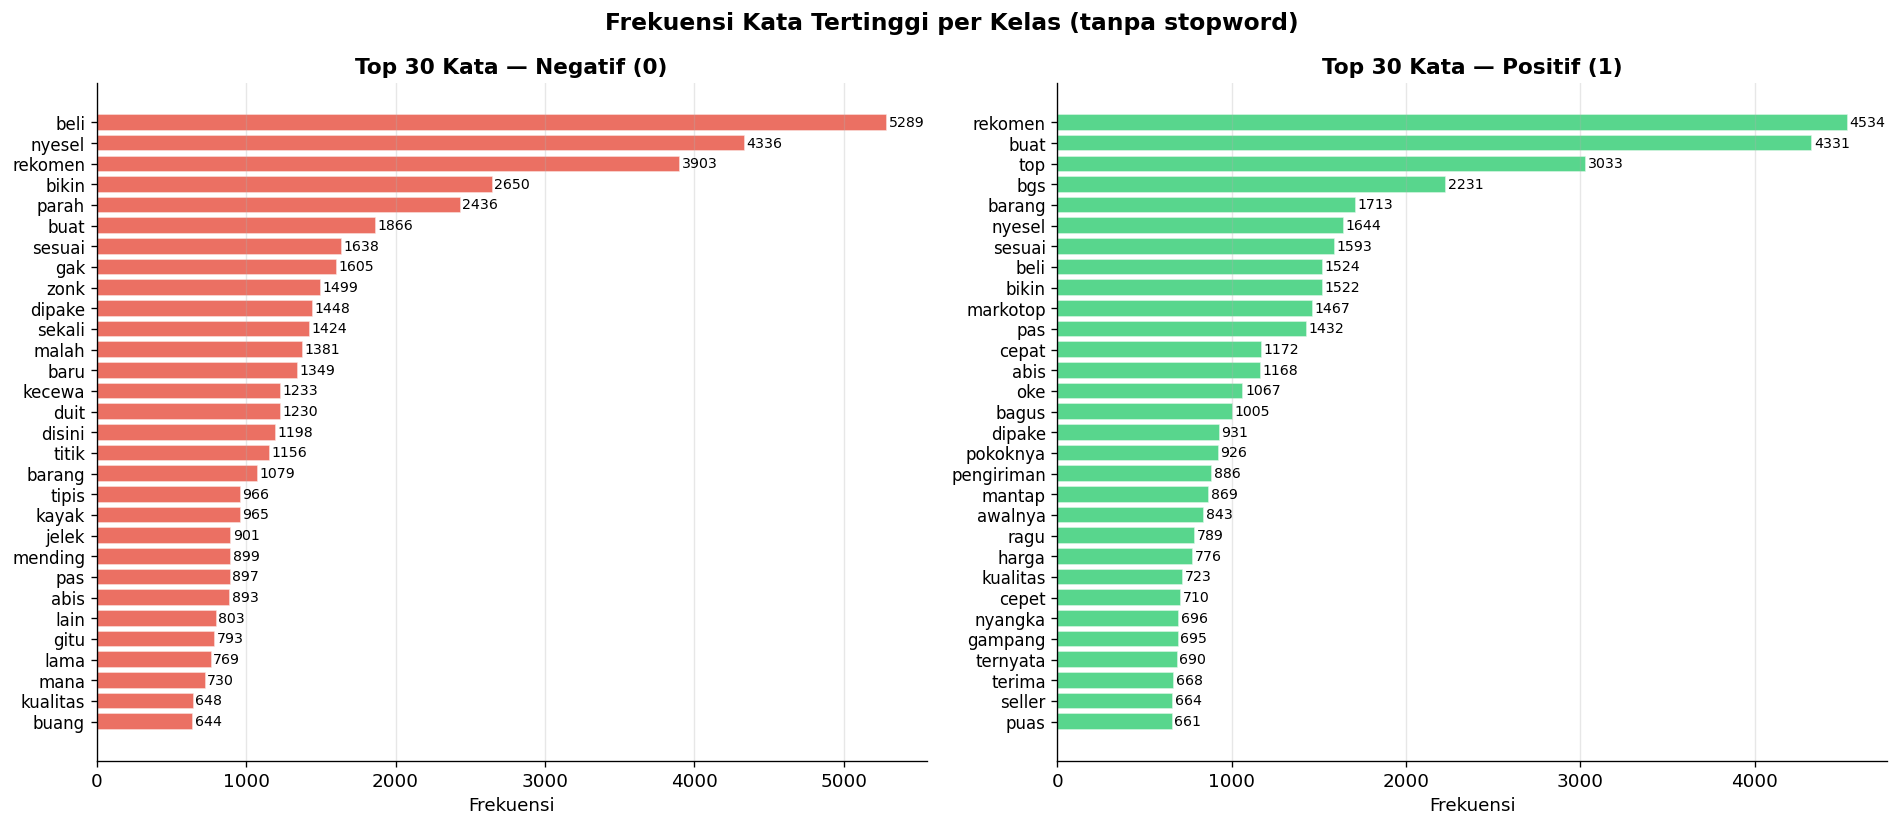

In [7]:
# Stopword sederhana Bahasa Indonesia
STOPWORDS = {
    'yang','dan','di','ke','dari','untuk','dengan','ini','itu','ya',
    'tidak','saya','aku','nya','juga','ada','tapi','tp','kalau','kalo',
    'pake','bisa','sudah','sdh','udah','udh','sangat','banget','bgt',
    'mau','mw','aja','sih','deh','kk','bg','ka','kak','om','bro',
    'yg','dgn','dr','utk','krn','sama','se','lg','lagi','hrs','harus',
    'lebih','lbh','or','the','and','to','of','in','is','a'
}

def top_words(texts, n=30, exclude=STOPWORDS):
    counter = Counter()
    for t in texts:
        tokens = re.sub(r'[^\w\s]', ' ', str(t).lower()).split()
        counter.update([tok for tok in tokens if tok not in exclude and len(tok) > 2])
    return counter.most_common(n)

neg_texts = df[df['sentiment']==0]['review_text']
pos_texts = df[df['sentiment']==1]['review_text']

neg_top = top_words(neg_texts)
pos_top = top_words(pos_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, tops, color, title in zip(
    axes,
    [neg_top, pos_top],
    PALETTE,
    ['Top 30 Kata — Negatif (0)', 'Top 30 Kata — Positif (1)']
):
    words, counts = zip(*tops)
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    ax.grid(axis='x', alpha=0.3)
    for i, (w, c) in enumerate(zip(words, counts)):
        ax.text(c + 10, i, str(c), va='center', fontsize=8.5)

plt.suptitle('Frekuensi Kata Tertinggi per Kelas (tanpa stopword)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. WordCloud per Kelas


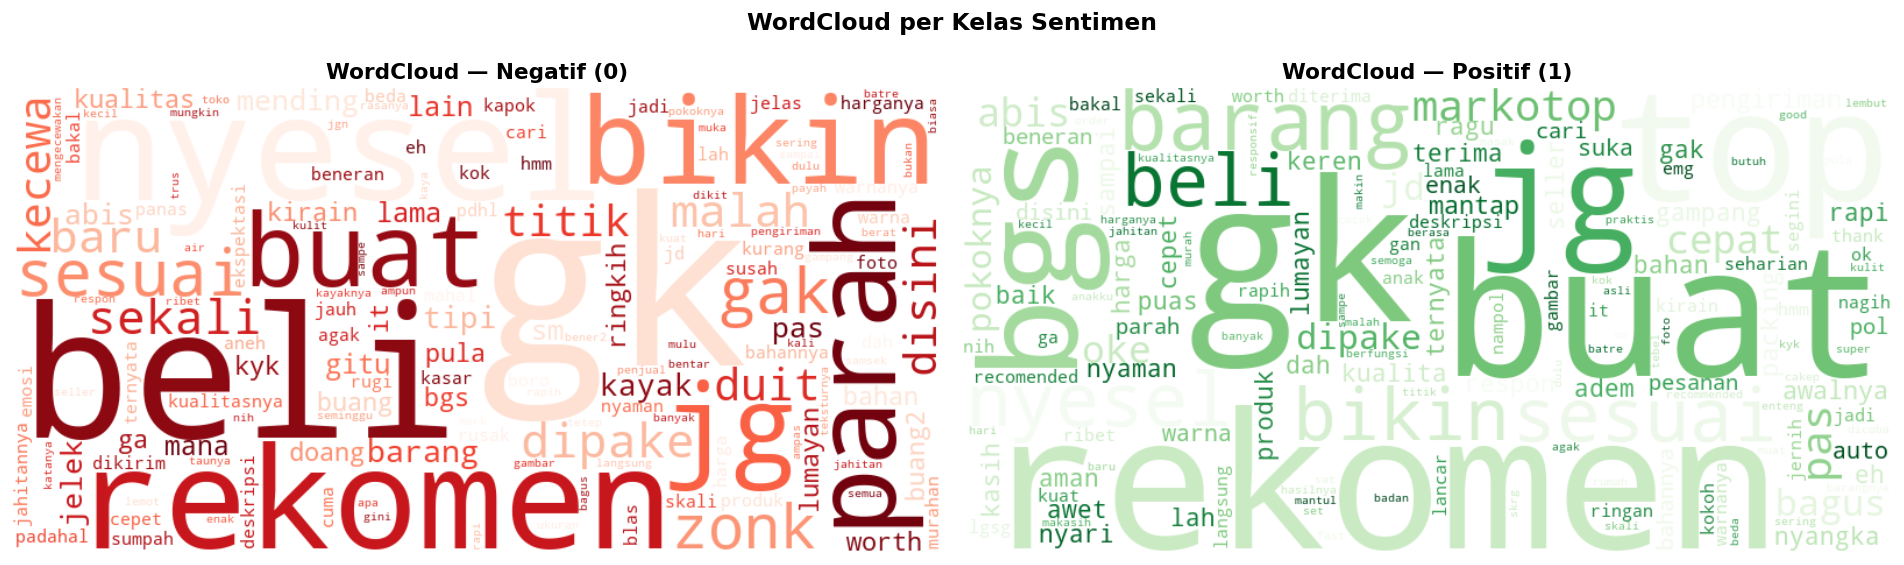

In [8]:
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print('⚠️  wordcloud tidak terinstall. Jalankan: pip install wordcloud')

if HAS_WORDCLOUD:
    def make_wordcloud(texts, color, title):
        text = ' '.join(re.sub(r'[^\w\s]', ' ', str(t).lower()) for t in texts)
        wc = WordCloud(
            width=800, height=400, background_color='white',
            colormap='Reds' if 'Negatif' in title else 'Greens',
            max_words=150, stopwords=STOPWORDS, collocations=False
        ).generate(text)
        return wc

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, texts, title in zip(
        axes,
        [neg_texts, pos_texts],
        ['WordCloud — Negatif (0)', 'WordCloud — Positif (1)']
    ):
        wc = make_wordcloud(texts, None, title)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.suptitle('WordCloud per Kelas Sentimen', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 6. Analisis Karakter Khusus


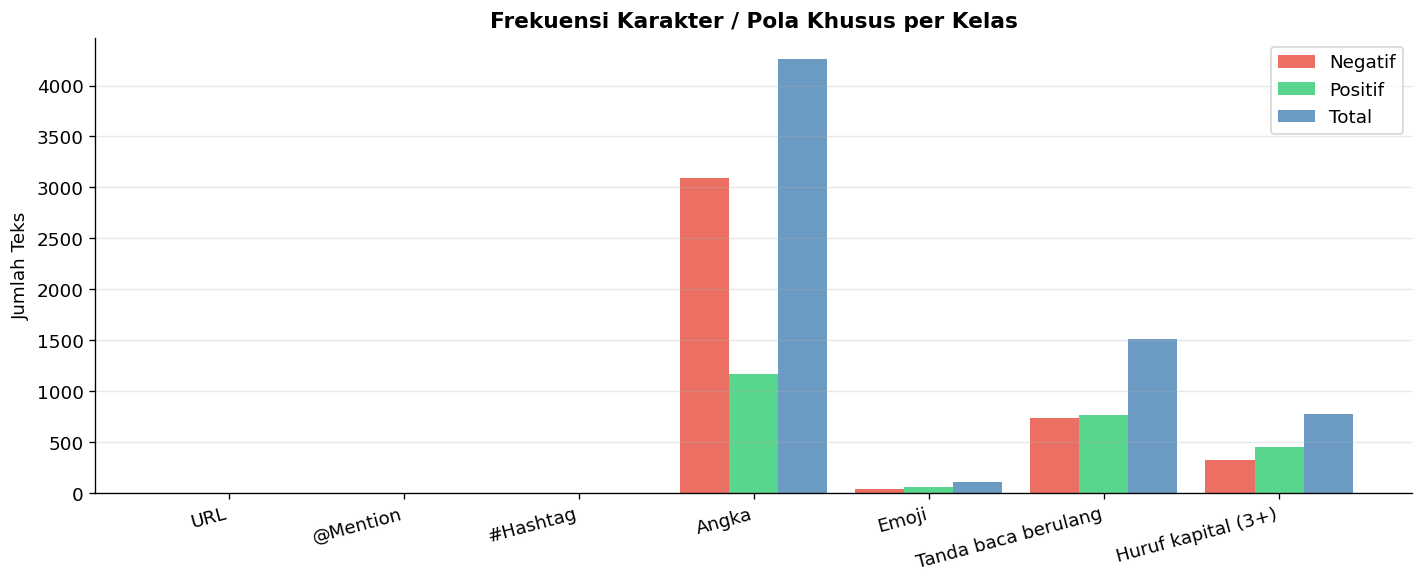


Ringkasan pola khusus (% dari total):
  URL                      :     0 (  0.0%)
  @Mention                 :     0 (  0.0%)
  #Hashtag                 :     0 (  0.0%)
  Angka                    : 4,257 ( 21.6%)
  Emoji                    :   108 (  0.5%)
  Tanda baca berulang      : 1,514 (  7.7%)
  Huruf kapital (3+)       :   779 (  3.9%)


In [9]:
# Deteksi pola-pola yang perlu ditangani saat preprocessing
df['has_url']      = df['review_text'].str.contains(r'https?://|www\.', regex=True)
df['has_mention']  = df['review_text'].str.contains(r'@\w+', regex=True)
df['has_hashtag']  = df['review_text'].str.contains(r'#\w+', regex=True)
df['has_number']   = df['review_text'].str.contains(r'\d', regex=True)
df['has_emoji']    = df['review_text'].str.contains(
    u'[\U0001F300-\U0001FFFF\U00002600-\U000027BF]', regex=True
)
df['has_punct_excess'] = df['review_text'].str.contains(r'[!?]{2,}|[\.]{3,}', regex=True)
df['has_caps']     = df['review_text'].str.contains(r'[A-Z]{3,}', regex=True)

features = ['has_url','has_mention','has_hashtag','has_number','has_emoji','has_punct_excess','has_caps']
labels_map = {
    'has_url': 'URL', 'has_mention': '@Mention', 'has_hashtag': '#Hashtag',
    'has_number': 'Angka', 'has_emoji': 'Emoji',
    'has_punct_excess': 'Tanda baca berulang', 'has_caps': 'Huruf kapital (3+)'
}

counts_all = {labels_map[f]: df[f].sum() for f in features}
counts_neg = {labels_map[f]: df[df['sentiment']==0][f].sum() for f in features}
counts_pos = {labels_map[f]: df[df['sentiment']==1][f].sum() for f in features}

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(features))
w = 0.28
b1 = ax.bar(x - w, [counts_neg[labels_map[f]] for f in features], w, label='Negatif', color=PALETTE[0], alpha=0.8)
b2 = ax.bar(x,     [counts_pos[labels_map[f]] for f in features], w, label='Positif', color=PALETTE[1], alpha=0.8)
b3 = ax.bar(x + w, [counts_all[labels_map[f]] for f in features], w, label='Total',   color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([labels_map[f] for f in features], rotation=15, ha='right')
ax.set_title('Frekuensi Karakter / Pola Khusus per Kelas', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Teks')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nRingkasan pola khusus (% dari total):')
for feat in features:
    pct = df[feat].sum() / len(df) * 100
    print(f'  {labels_map[feat]:<25}: {df[feat].sum():>5,} ({pct:5.1f}%)')

---
## 7. Deteksi Duplikat & Missing Values


In [10]:
n_dup = df.duplicated(subset='review_text').sum()
n_miss = df['review_text'].isnull().sum()
n_empty = (df['review_text'].str.strip() == '').sum()

print('=' * 50)
print('  DATA QUALITY CHECK')
print('=' * 50)
print(f'  Total baris        : {len(df):,}')
print(f'  Missing values     : {n_miss}')
print(f'  String kosong      : {n_empty}')
print(f'  Duplikat teks      : {n_dup}')
print('=' * 50)

if n_dup > 0:
    print(f'\n⚠️  Contoh duplikat:')
    dup_df = df[df.duplicated(subset='review_text', keep=False)].sort_values('review_text')
    print(dup_df[['review_text','sentiment']].head(6).to_string())
else:
    print('\n✅ Tidak ada duplikat')

# Teks sangat pendek (< 3 kata)
very_short = df[df['word_count'] < 3]
print(f'\n  Teks sangat pendek (< 3 kata): {len(very_short)} baris')
if len(very_short) > 0:
    print(very_short[['review_text','sentiment']].head(5).to_string())

  DATA QUALITY CHECK
  Total baris        : 19,728
  Missing values     : 0
  String kosong      : 0
  Duplikat teks      : 0

✅ Tidak ada duplikat

  Teks sangat pendek (< 3 kata): 104 baris
         review_text  sentiment
299           suck .          0
699    lama kirimnya          0
824   gampang penyok          0
1008   bocorr isinya          0
1215      lama nympe          0


---
## 8. Ringkasan & Rekomendasi Preprocessing


In [11]:
print('=' * 60)
print('  RINGKASAN EDA')
print('=' * 60)
print(f'  Dataset          : {len(df):,} ulasan e-commerce Bahasa Indonesia')
print(f'  Kelas            : Seimbang — {label_counts[0]:,} Negatif / {label_counts[1]:,} Positif')
print(f'  Rata-rata kata   : {df["word_count"].mean():.1f} kata/ulasan')
print(f'  Median kata      : {df["word_count"].median():.0f} kata/ulasan')
print(f'  Max kata         : {df["word_count"].max()}')
print(f'  Duplikat         : {n_dup}')
print()

  RINGKASAN EDA
  Dataset          : 19,728 ulasan e-commerce Bahasa Indonesia
  Kelas            : Seimbang — 9,864 Negatif / 9,864 Positif
  Rata-rata kata   : 21.9 kata/ulasan
  Median kata      : 21 kata/ulasan
  Max kata         : 122
  Duplikat         : 0

